In [1]:
#path and file handling
import pathlib
import nd2
import os
import tifffile

In [65]:
#SET path for ND2 and Tiff files
nd2_path = pathlib.Path("/Volumes/ScientificData/Users/Giulia(botgiu00)/Papers/bottacin2025/Image_Data/Figure5/5A_checkerboards")
tiff_path = pathlib.Path("/Volumes/ScientificData/Users/Giulia(botgiu00)/Papers/bottacin2025/Image_Data/Figure5/5A_checkerboards")

#set file name of nd2 file (leave out .nd2)
file_name = "small_rep2_before_AB"

# Set channel index (optional if there are multiple channels)
channel = 2
channel_name = 'phase'

#set position number
pos = 1

In [66]:
#create file names
data_file = nd2_path / f"{file_name}.nd2"
f = nd2.ND2File(data_file)
raw_data = f.to_dask()
#see metadata https://pypi.org/project/nd2/
print(f.metadata.channels)
print(f.experiment)
num_dimensions = raw_data.ndim
print(f"Number of dimensions: {num_dimensions}")
print(f.sizes)
f.close()

[Channel(channel=ChannelMeta(name='mcherry', index=0, color=Color(r=255, g=42, b=0, a=1.0), emissionLambdaNm=630.0, excitationLambdaNm=575.0), loops=LoopIndices(NETimeLoop=None, TimeLoop=0, XYPosLoop=1, ZStackLoop=None), microscope=Microscope(objectiveMagnification=10.0, objectiveName='Achromat 10x Ph1 ADL', objectiveNumericalAperture=0.25, zoomMagnification=1.0, immersionRefractiveIndex=1.0, projectiveMagnification=None, pinholeDiameterUm=None, modalityFlags=['fluorescence', 'camera']), volume=Volume(axesCalibrated=(True, True, False), axesCalibration=(0.65, 0.65, 1.0), axesInterpretation=('distance', 'distance', 'distance'), bitsPerComponentInMemory=16, bitsPerComponentSignificant=16, cameraTransformationMatrix=(-0.9999616468822087, 0.00875812563400387, -0.00875812563400387, -0.9999616468822087), componentCount=1, componentDataType='unsigned', voxelCount=(2304, 2304, 1), componentMaxima=[0.0], componentMinima=[0.0], pixelToStageTransformationMatrix=None)), Channel(channel=ChannelMeta

In [67]:
if raw_data.ndim == 3:
    # Shape: (C, Y, X) - select specific channel
    pos_data = raw_data[channel, :, :]  # ✅ Correct
    
elif raw_data.ndim == 4:
    pos_data = raw_data[pos, channel, :, :]
    
elif raw_data.ndim == 5:
    pos_data = raw_data[0, pos, channel, :, :]  # Fixed: use index 0, not slice 1:2

# create the output TIFF file path
output_path = tiff_path / f"{file_name}_pos{pos}_{channel_name}.tif"

#remove old tif file if it exists
if os.path.exists(output_path):
    os.remove(output_path)

tifffile.imwrite(output_path, pos_data.compute())

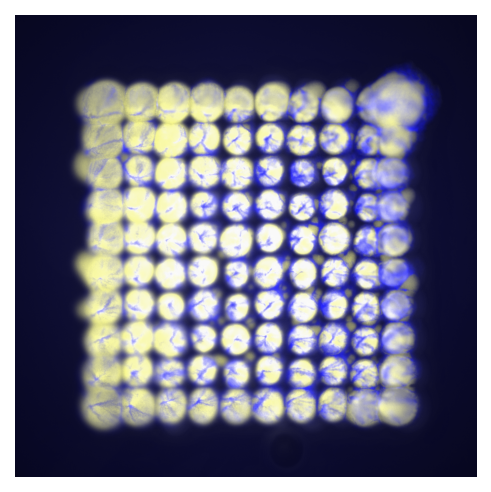

In [156]:
# -------- DISPLAY PARAMETERS --------
PHASE_PMIN, PHASE_PMAX = 1, 100
GFP_VMIN, GFP_VMAX = 1, 5000
MCH_VMIN, MCH_VMAX = 1, 5000
GAMMA = 1  # <1 brightens midtones
ALPHA = 0.98  # higher = brighter overlay
# -------------------------------------

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread
from skimage.exposure import rescale_intensity

# -------- CHARTOSAUR STYLE --------
plt.rcParams.update({
    'font.family': 'Arial', 'font.size': 8,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'savefig.dpi': 300, 'savefig.bbox': 'tight'
})

# -------- FILE PATHS --------
base = Path("/Volumes/ScientificData/Users/Giulia(botgiu00)/Papers/bottacin2025/Image_Data/Figure5/5A_checkerboards")
phase = imread(base / "mixed_rep2_before_AB_pos1_phase.tif")
gfp = imread(base / "mixed_rep2_before_AB_pos1_gfp.tif")
mch = imread(base / "mixed_rep2_before_AB_pos1_mcherry.tif")

# -------- NORMALIZE FUNCTIONS --------
def normalize(img, vmin, vmax, gamma=1.0):
    img = img.astype(float)
    vmin = img.min() if vmin is None else vmin
    vmax = img.max() if vmax is None else vmax
    img = np.clip((img - vmin) / (vmax - vmin), 0, 1)
    return img ** gamma  # gamma < 1 brightens

# -------- PROCESS IMAGES --------
phase_disp = rescale_intensity(phase, in_range=(
    np.percentile(phase, PHASE_PMIN), np.percentile(phase, PHASE_PMAX)))
gfp_norm = normalize(gfp, GFP_VMIN, GFP_VMAX, GAMMA)
mch_norm = normalize(mch, MCH_VMIN, MCH_VMAX, GAMMA)

# -------- CREATE MERGE FIGURE --------
fig, ax = plt.subplots(figsize=(3, 2))

ax.imshow(phase_disp, cmap='gray')
rgb_merge = np.zeros(phase.shape + (3,), dtype=np.float32)
rgb_merge[..., 0] = mch_norm  # yellow = R + G
rgb_merge[..., 1] = mch_norm  # yellow = R + G
rgb_merge[..., 2] = gfp_norm  # blue
ax.imshow(rgb_merge, alpha=ALPHA)
ax.axis('off')

fig.savefig(base / "mixed_blue_yellow_overlay.pdf", dpi=300)
plt.show()

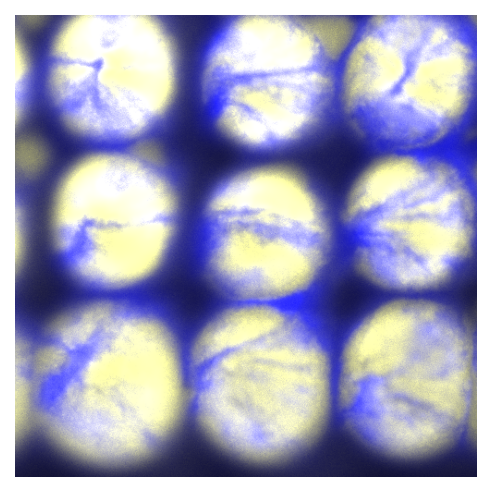

In [142]:
# -------- DISPLAY PARAMETERS --------
PHASE_PMIN, PHASE_PMAX = 1, 100
GFP_VMIN, GFP_VMAX = 1, 5000
MCH_VMIN, MCH_VMAX = 1, 5000
GAMMA = 1
ALPHA = 1
# -------- CROP (set to None for full image) --------
CROP = (1550, 2050, 1160, 1660)  # (y_start, y_end, x_start, x_end)
# CROP = None  # uncomment for full image
# -------------------------------------

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread
from skimage.exposure import rescale_intensity

# -------- CHARTOSAUR STYLE --------
plt.rcParams.update({
    'font.family': 'Arial', 'font.size': 8,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'savefig.dpi': 300, 'savefig.bbox': 'tight'
})

# -------- FILE PATHS --------
base = Path("/Volumes/ScientificData/Users/Giulia(botgiu00)/Papers/bottacin2025/Image_Data/Figure5/5A_checkerboards")
phase = imread(base / "mixed_rep2_before_AB_pos1_phase.tif")
gfp = imread(base / "mixed_rep2_before_AB_pos1_gfp.tif")
mch = imread(base / "mixed_rep2_before_AB_pos1_mcherry.tif")

# -------- APPLY CROP --------
if CROP is not None:
    y0, y1, x0, x1 = CROP
    phase = phase[y0:y1, x0:x1]
    gfp = gfp[y0:y1, x0:x1]
    mch = mch[y0:y1, x0:x1]

# -------- NORMALIZE FUNCTIONS --------
def normalize(img, vmin, vmax, gamma=1.0):
    img = img.astype(float)
    vmin = img.min() if vmin is None else vmin
    vmax = img.max() if vmax is None else vmax
    img = np.clip((img - vmin) / (vmax - vmin), 0, 1)
    return img ** gamma

# -------- PROCESS IMAGES --------
phase_disp = rescale_intensity(phase, in_range=(
    np.percentile(phase, PHASE_PMIN), np.percentile(phase, PHASE_PMAX)))
gfp_norm = normalize(gfp, GFP_VMIN, GFP_VMAX, GAMMA)
mch_norm = normalize(mch, MCH_VMIN, MCH_VMAX, GAMMA)

# -------- CREATE MERGE FIGURE --------
fig, ax = plt.subplots(figsize=(3, 2))

ax.imshow(phase_disp, cmap='gray')
rgb_merge = np.zeros(phase.shape + (3,), dtype=np.float32)
rgb_merge[..., 0] = mch_norm  # yellow = R + G
rgb_merge[..., 1] = mch_norm  # yellow = R + G
rgb_merge[..., 2] = gfp_norm  # blue
ax.imshow(rgb_merge, alpha=ALPHA)
ax.axis('off')

fig.savefig(base / "mixed_blue_yellow_overlay_cropped.pdf", dpi=300)
plt.show()

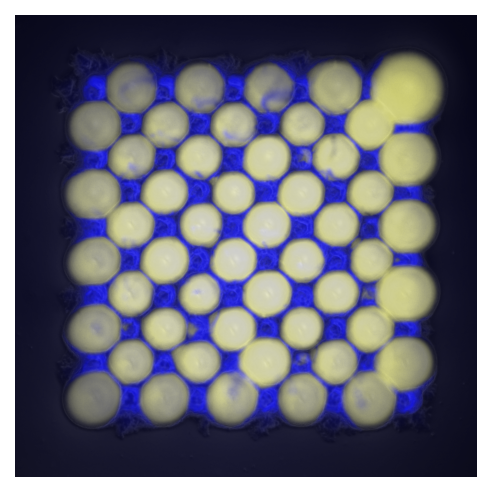

In [126]:
# -------- DISPLAY PARAMETERS --------
PHASE_PMIN, PHASE_PMAX = 1, 100
GFP_VMIN, GFP_VMAX = 1, 5000
MCH_VMIN, MCH_VMAX = 1, 5000
GAMMA = 1  # <1 brightens midtones
ALPHA = 0.8  # higher = brighter overlay
# -------------------------------------

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread
from skimage.exposure import rescale_intensity

# -------- CHARTOSAUR STYLE --------
plt.rcParams.update({
    'font.family': 'Arial', 'font.size': 8,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'savefig.dpi': 300, 'savefig.bbox': 'tight'
})

# -------- FILE PATHS --------
base = Path("/Volumes/ScientificData/Users/Giulia(botgiu00)/Papers/bottacin2025/Image_Data/Figure5/5A_checkerboards")
phase = imread(base / "small_rep2_before_AB_pos1_phase.tif")
gfp = imread(base / "small_rep2_before_AB_pos1_gfp.tif")
mch = imread(base / "small_rep2_before_AB_pos1_mcherry.tif")

# -------- NORMALIZE FUNCTIONS --------
def normalize(img, vmin, vmax, gamma=1.0):
    img = img.astype(float)
    vmin = img.min() if vmin is None else vmin
    vmax = img.max() if vmax is None else vmax
    img = np.clip((img - vmin) / (vmax - vmin), 0, 1)
    return img ** gamma  # gamma < 1 brightens

# -------- PROCESS IMAGES --------
phase_disp = rescale_intensity(phase, in_range=(
    np.percentile(phase, PHASE_PMIN), np.percentile(phase, PHASE_PMAX)))
gfp_norm = normalize(gfp, GFP_VMIN, GFP_VMAX, GAMMA)
mch_norm = normalize(mch, MCH_VMIN, MCH_VMAX, GAMMA)

# -------- CREATE MERGE FIGURE --------
fig, ax = plt.subplots(figsize=(3, 2))

ax.imshow(phase_disp, cmap='gray')
rgb_merge = np.zeros(phase.shape + (3,), dtype=np.float32)
rgb_merge[..., 0] = mch_norm  # yellow = R + G
rgb_merge[..., 1] = mch_norm  # yellow = R + G
rgb_merge[..., 2] = gfp_norm  # blue
ax.imshow(rgb_merge, alpha=ALPHA)
ax.axis('off')

fig.savefig(base / "small_blue_yellow_overlay.pdf", dpi=300)
plt.show()

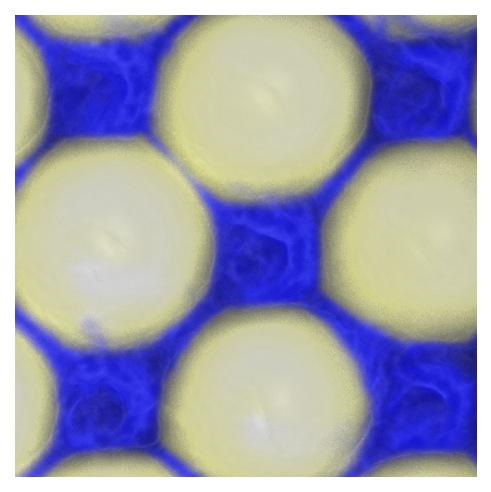

In [154]:
# -------- DISPLAY PARAMETERS --------
PHASE_PMIN, PHASE_PMAX = 1, 100
GFP_VMIN, GFP_VMAX = 1, 5000
MCH_VMIN, MCH_VMAX = 1, 5000
GAMMA = 1
ALPHA = 0.8
# -------- CROP (set to None for full image) --------
CROP = (800, 1300, 1160, 1660)  # (y_start, y_end, x_start, x_end)
# CROP = None  # uncomment for full image
# -------------------------------------

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread
from skimage.exposure import rescale_intensity

# -------- CHARTOSAUR STYLE --------
plt.rcParams.update({
    'font.family': 'Arial', 'font.size': 8,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'savefig.dpi': 300, 'savefig.bbox': 'tight'
})

# -------- FILE PATHS --------
base = Path("/Volumes/ScientificData/Users/Giulia(botgiu00)/Papers/bottacin2025/Image_Data/Figure5/5A_checkerboards")
phase = imread(base / "small_rep2_before_AB_pos1_phase.tif")
gfp = imread(base / "small_rep2_before_AB_pos1_gfp.tif")
mch = imread(base / "small_rep2_before_AB_pos1_mcherry.tif")

# -------- APPLY CROP --------
if CROP is not None:
    y0, y1, x0, x1 = CROP
    phase = phase[y0:y1, x0:x1]
    gfp = gfp[y0:y1, x0:x1]
    mch = mch[y0:y1, x0:x1]

# -------- NORMALIZE FUNCTIONS --------
def normalize(img, vmin, vmax, gamma=1.0):
    img = img.astype(float)
    vmin = img.min() if vmin is None else vmin
    vmax = img.max() if vmax is None else vmax
    img = np.clip((img - vmin) / (vmax - vmin), 0, 1)
    return img ** gamma

# -------- PROCESS IMAGES --------
phase_disp = rescale_intensity(phase, in_range=(
    np.percentile(phase, PHASE_PMIN), np.percentile(phase, PHASE_PMAX)))
gfp_norm = normalize(gfp, GFP_VMIN, GFP_VMAX, GAMMA)
mch_norm = normalize(mch, MCH_VMIN, MCH_VMAX, GAMMA)

# -------- CREATE MERGE FIGURE --------
fig, ax = plt.subplots(figsize=(3, 2))

ax.imshow(phase_disp, cmap='gray')
rgb_merge = np.zeros(phase.shape + (3,), dtype=np.float32)
rgb_merge[..., 0] = mch_norm  # yellow = R + G
rgb_merge[..., 1] = mch_norm  # yellow = R + G
rgb_merge[..., 2] = gfp_norm  # blue
ax.imshow(rgb_merge, alpha=ALPHA)
ax.axis('off')

fig.savefig(base / "small_blue_yellow_overlay_cropped.pdf", dpi=300)
plt.show()

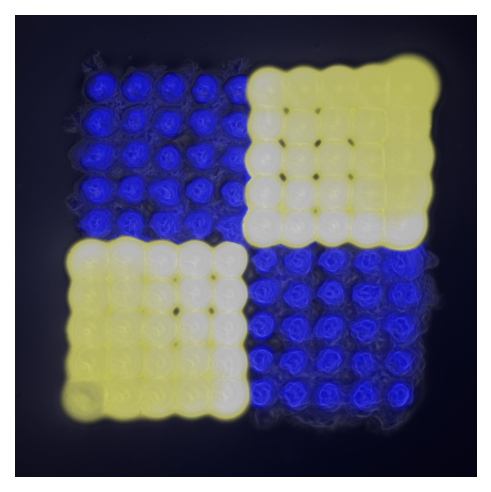

In [124]:
# -------- DISPLAY PARAMETERS --------
PHASE_PMIN, PHASE_PMAX = 1, 100
GFP_VMIN, GFP_VMAX = 1, 5000
MCH_VMIN, MCH_VMAX = 1, 5000
GAMMA = 1  # <1 brightens midtones
ALPHA = 0.7  # higher = brighter overlay
# -------------------------------------

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread
from skimage.exposure import rescale_intensity

# -------- CHARTOSAUR STYLE --------
plt.rcParams.update({
    'font.family': 'Arial', 'font.size': 8,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'savefig.dpi': 300, 'savefig.bbox': 'tight'
})

# -------- FILE PATHS --------
base = Path("/Volumes/ScientificData/Users/Giulia(botgiu00)/Papers/bottacin2025/Image_Data/Figure5/5A_checkerboards")
phase = imread(base / "big_rep1_before_AB_pos1_phase.tif")
gfp = imread(base / "big_rep1_before_AB_pos1_gfp.tif")
mch = imread(base / "big_rep1_before_AB_pos1_mcherry.tif")

# -------- NORMALIZE FUNCTIONS --------
def normalize(img, vmin, vmax, gamma=1.0):
    img = img.astype(float)
    vmin = img.min() if vmin is None else vmin
    vmax = img.max() if vmax is None else vmax
    img = np.clip((img - vmin) / (vmax - vmin), 0, 1)
    return img ** gamma  # gamma < 1 brightens

# -------- PROCESS IMAGES --------
phase_disp = rescale_intensity(phase, in_range=(
    np.percentile(phase, PHASE_PMIN), np.percentile(phase, PHASE_PMAX)))
gfp_norm = normalize(gfp, GFP_VMIN, GFP_VMAX, GAMMA)
mch_norm = normalize(mch, MCH_VMIN, MCH_VMAX, GAMMA)

# -------- CREATE MERGE FIGURE --------
fig, ax = plt.subplots(figsize=(3, 2))

ax.imshow(phase_disp, cmap='gray')
rgb_merge = np.zeros(phase.shape + (3,), dtype=np.float32)
rgb_merge[..., 0] = mch_norm  # yellow = R + G
rgb_merge[..., 1] = mch_norm  # yellow = R + G
rgb_merge[..., 2] = gfp_norm  # blue
ax.imshow(rgb_merge, alpha=ALPHA)
ax.axis('off')

fig.savefig(base / "big_blue_yellow_overlay.pdf", dpi=300)
plt.show()

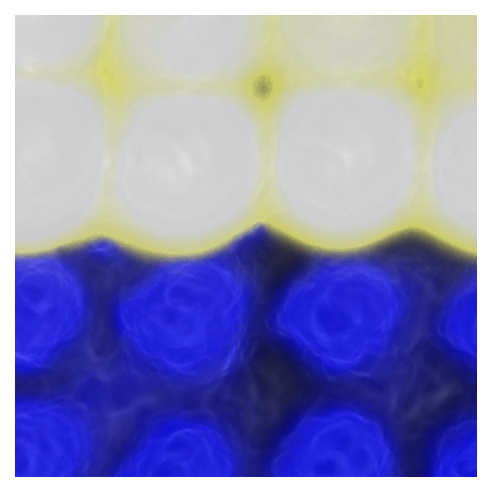

In [177]:
# -------- DISPLAY PARAMETERS --------
PHASE_PMIN, PHASE_PMAX = 1, 100
GFP_VMIN, GFP_VMAX = 1, 5000
MCH_VMIN, MCH_VMAX = 1, 5000
GAMMA = 1
ALPHA = 0.8
# -------- CROP (set to None for full image) --------
CROP = (900, 1400, 1230, 1730)  # (y_start, y_end, x_start, x_end)
# CROP = None  # uncomment for full image
# -------------------------------------

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread
from skimage.exposure import rescale_intensity

# -------- CHARTOSAUR STYLE --------
plt.rcParams.update({
    'font.family': 'Arial', 'font.size': 8,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'savefig.dpi': 300, 'savefig.bbox': 'tight'
})

# -------- FILE PATHS --------
base = Path("/Volumes/ScientificData/Users/Giulia(botgiu00)/Papers/bottacin2025/Image_Data/Figure5/5A_checkerboards")
phase = imread(base / "big_rep1_before_AB_pos1_phase.tif")
gfp = imread(base / "big_rep1_before_AB_pos1_gfp.tif")
mch = imread(base / "big_rep1_before_AB_pos1_mcherry.tif")

# -------- APPLY CROP --------
if CROP is not None:
    y0, y1, x0, x1 = CROP
    phase = phase[y0:y1, x0:x1]
    gfp = gfp[y0:y1, x0:x1]
    mch = mch[y0:y1, x0:x1]

# -------- NORMALIZE FUNCTIONS --------
def normalize(img, vmin, vmax, gamma=1.0):
    img = img.astype(float)
    vmin = img.min() if vmin is None else vmin
    vmax = img.max() if vmax is None else vmax
    img = np.clip((img - vmin) / (vmax - vmin), 0, 1)
    return img ** gamma

# -------- PROCESS IMAGES --------
phase_disp = rescale_intensity(phase, in_range=(
    np.percentile(phase, PHASE_PMIN), np.percentile(phase, PHASE_PMAX)))
gfp_norm = normalize(gfp, GFP_VMIN, GFP_VMAX, GAMMA)
mch_norm = normalize(mch, MCH_VMIN, MCH_VMAX, GAMMA)

# -------- CREATE MERGE FIGURE --------
fig, ax = plt.subplots(figsize=(3, 2))

ax.imshow(phase_disp, cmap='gray')
rgb_merge = np.zeros(phase.shape + (3,), dtype=np.float32)
rgb_merge[..., 0] = mch_norm  # yellow = R + G
rgb_merge[..., 1] = mch_norm  # yellow = R + G
rgb_merge[..., 2] = gfp_norm  # blue
ax.imshow(rgb_merge, alpha=ALPHA)
ax.axis('off')

fig.savefig(base / "big_blue_yellow_overlay_cropped.pdf", dpi=300)
plt.show()

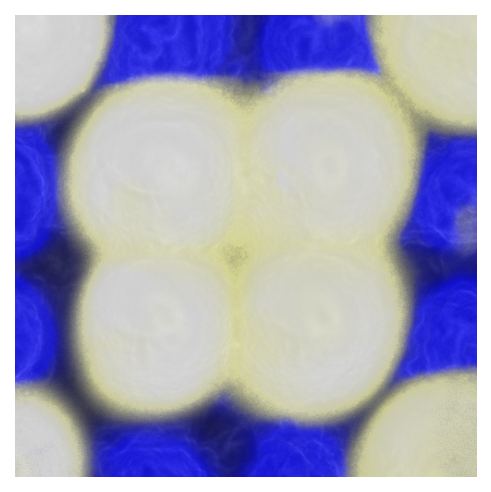

In [170]:
# -------- DISPLAY PARAMETERS --------
PHASE_PMIN, PHASE_PMAX = 1, 100
GFP_VMIN, GFP_VMAX = 1, 5000
MCH_VMIN, MCH_VMAX = 1, 5000
GAMMA = 1
ALPHA = 0.8
# -------- CROP (set to None for full image) --------
CROP = (1200, 1700, 1230, 1730)  # (y_start, y_end, x_start, x_end)
# CROP = None  # uncomment for full image
# -------------------------------------

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread
from skimage.exposure import rescale_intensity

# -------- CHARTOSAUR STYLE --------
plt.rcParams.update({
    'font.family': 'Arial', 'font.size': 8,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'savefig.dpi': 300, 'savefig.bbox': 'tight'
})

# -------- FILE PATHS --------
base = Path("/Volumes/ScientificData/Users/Giulia(botgiu00)/Papers/bottacin2025/Image_Data/Figure5/5A_checkerboards")
phase = imread(base / "medium_rep1_before_AB_pos1_phase.tif")
gfp = imread(base / "medium_rep1_before_AB_pos1_gfp.tif")
mch = imread(base / "medium_rep1_before_AB_pos1_mcherry.tif")

# -------- APPLY CROP --------
if CROP is not None:
    y0, y1, x0, x1 = CROP
    phase = phase[y0:y1, x0:x1]
    gfp = gfp[y0:y1, x0:x1]
    mch = mch[y0:y1, x0:x1]

# -------- NORMALIZE FUNCTIONS --------
def normalize(img, vmin, vmax, gamma=1.0):
    img = img.astype(float)
    vmin = img.min() if vmin is None else vmin
    vmax = img.max() if vmax is None else vmax
    img = np.clip((img - vmin) / (vmax - vmin), 0, 1)
    return img ** gamma

# -------- PROCESS IMAGES --------
phase_disp = rescale_intensity(phase, in_range=(
    np.percentile(phase, PHASE_PMIN), np.percentile(phase, PHASE_PMAX)))
gfp_norm = normalize(gfp, GFP_VMIN, GFP_VMAX, GAMMA)
mch_norm = normalize(mch, MCH_VMIN, MCH_VMAX, GAMMA)

# -------- CREATE MERGE FIGURE --------
fig, ax = plt.subplots(figsize=(3, 2))

ax.imshow(phase_disp, cmap='gray')
rgb_merge = np.zeros(phase.shape + (3,), dtype=np.float32)
rgb_merge[..., 0] = mch_norm  # yellow = R + G
rgb_merge[..., 1] = mch_norm  # yellow = R + G
rgb_merge[..., 2] = gfp_norm  # blue
ax.imshow(rgb_merge, alpha=ALPHA)
ax.axis('off')

fig.savefig(base / "medium_blue_yellow_overlay_cropped.pdf", dpi=300)
plt.show()

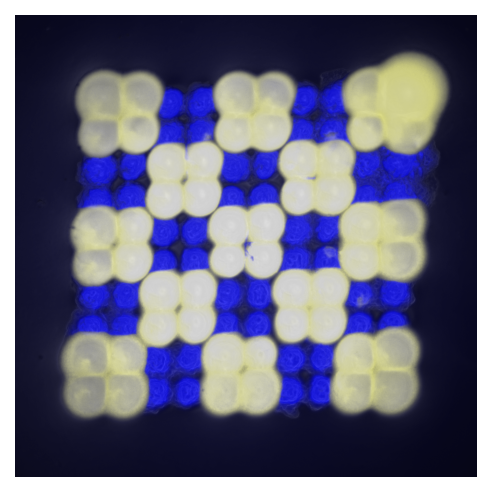

In [123]:
# -------- DISPLAY PARAMETERS --------
PHASE_PMIN, PHASE_PMAX = 1, 100
GFP_VMIN, GFP_VMAX = 1, 5000
MCH_VMIN, MCH_VMAX = 1, 5000
GAMMA = 1  # <1 brightens midtones
ALPHA = 0.8  # higher = brighter overlay
# -------------------------------------

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread
from skimage.exposure import rescale_intensity

# -------- CHARTOSAUR STYLE --------
plt.rcParams.update({
    'font.family': 'Arial', 'font.size': 8,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'savefig.dpi': 300, 'savefig.bbox': 'tight'
})

# -------- FILE PATHS --------
base = Path("/Volumes/ScientificData/Users/Giulia(botgiu00)/Papers/bottacin2025/Image_Data/Figure5/5A_checkerboards")
phase = imread(base / "medium_rep1_before_AB_pos1_phase.tif")
gfp = imread(base / "medium_rep1_before_AB_pos1_gfp.tif")
mch = imread(base / "medium_rep1_before_AB_pos1_mcherry.tif")

# -------- NORMALIZE FUNCTIONS --------
def normalize(img, vmin, vmax, gamma=1.0):
    img = img.astype(float)
    vmin = img.min() if vmin is None else vmin
    vmax = img.max() if vmax is None else vmax
    img = np.clip((img - vmin) / (vmax - vmin), 0, 1)
    return img ** gamma  # gamma < 1 brightens

# -------- PROCESS IMAGES --------
phase_disp = rescale_intensity(phase, in_range=(
    np.percentile(phase, PHASE_PMIN), np.percentile(phase, PHASE_PMAX)))
gfp_norm = normalize(gfp, GFP_VMIN, GFP_VMAX, GAMMA)
mch_norm = normalize(mch, MCH_VMIN, MCH_VMAX, GAMMA)

# -------- CREATE MERGE FIGURE --------
fig, ax = plt.subplots(figsize=(3, 2))

ax.imshow(phase_disp, cmap='gray')
rgb_merge = np.zeros(phase.shape + (3,), dtype=np.float32)
rgb_merge[..., 0] = mch_norm  # yellow = R + G
rgb_merge[..., 1] = mch_norm  # yellow = R + G
rgb_merge[..., 2] = gfp_norm  # blue
ax.imshow(rgb_merge, alpha=ALPHA)
ax.axis('off')

fig.savefig(base / "medium_blue_yellow_overlay.pdf", dpi=300)
plt.show()